<a href="https://colab.research.google.com/github/sasaitals/MachineLearning/blob/main/MachineLearning/Aula3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd

uri = "https://gist.githubusercontent.com/guilhermesilveira/12291c548acaf544596795709020e3db/raw/325bdef098bd9cbc2189215b7e32e22f437f29f3/projetos.csv"
dados =pd.read_csv(uri)
dados.head()

,nao_finalizado,horas_esperadas,preco
0,0,75.0,6985.000000
1,1,0.0,4325.293458
2,0,87.0,14205.000000
3,1,13.0,100.000000
4,0,2.0,202.000000


In [61]:
dados["finalizado"] = dados["nao_finalizado"].map({1: 0, 0: 1})
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizado
0,0,75.0,6985.000000,1
1,1,0.0,4325.293458,0
2,0,87.0,14205.000000,1
3,1,13.0,100.000000,0
4,0,2.0,202.000000,1


<Axes: xlabel='horas_esperadas', ylabel='preco'>

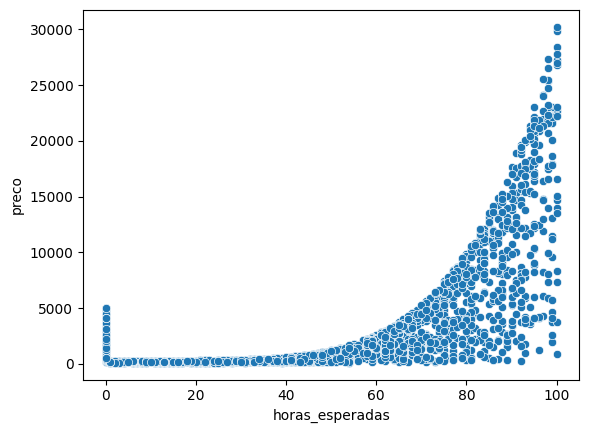

In [62]:
import seaborn as sns
sns.scatterplot(x="horas_esperadas", y="preco", data=dados)

<Axes: xlabel='horas_esperadas', ylabel='preco'>

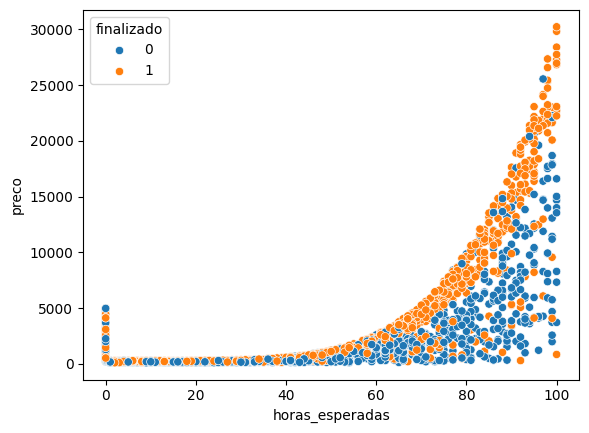

In [63]:
sns.scatterplot(x="horas_esperadas", y="preco", data=dados, hue="finalizado")

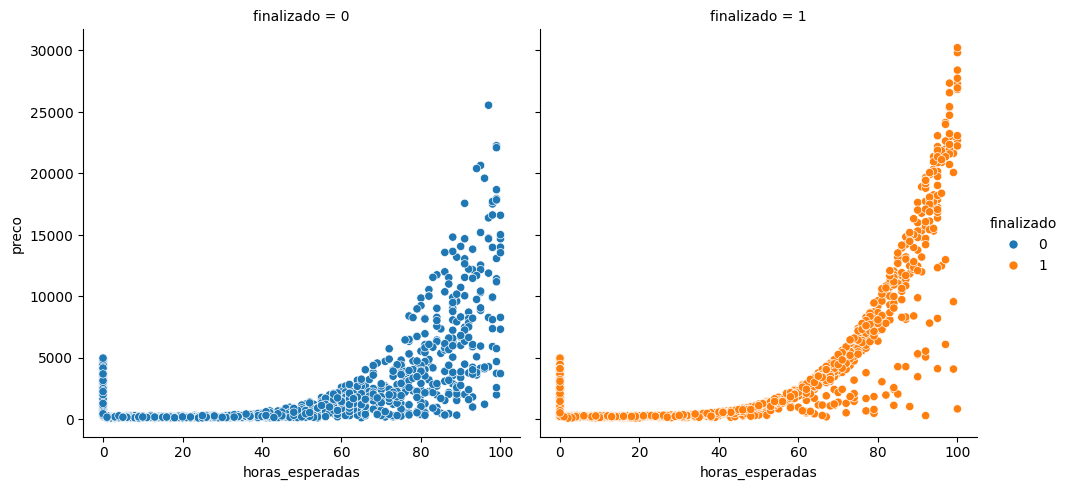

In [64]:
sns.relplot(x="horas_esperadas", y="preco", data=dados, hue="finalizado", col="finalizado")

In [65]:
# jogar fora as linhas com hora_esperadas = 0
dados = dados.query("horas_esperadas > 0")
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizado
0,0,75.0,6985.0,1
2,0,87.0,14205.0,1
3,1,13.0,100.0,0
4,0,2.0,202.0,1
5,0,49.0,1096.0,1


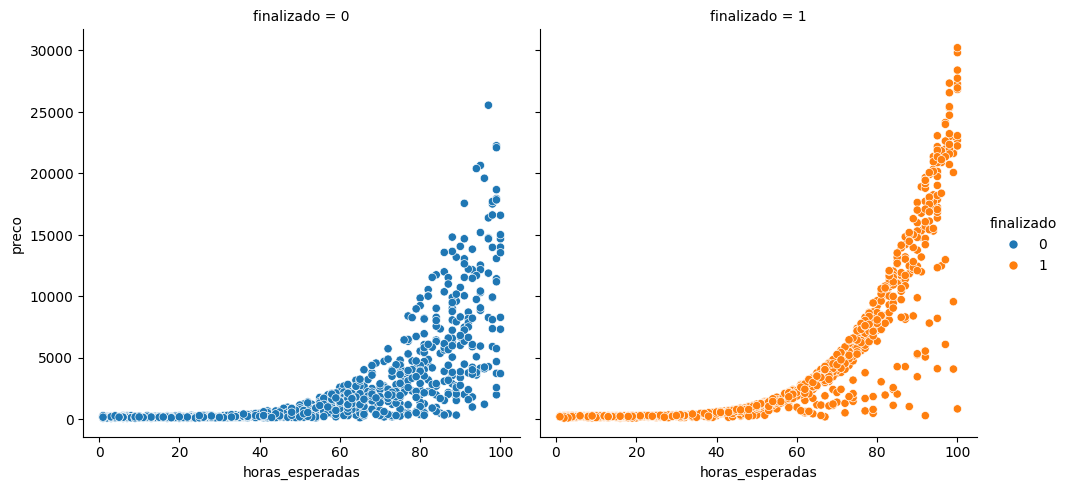

In [66]:
sns.relplot(x="horas_esperadas", y="preco", data=dados, hue="finalizado", col="finalizado")

In [67]:
x = dados[["horas_esperadas", "preco"]] #x são as carateristicas e o y é o alvo que queremos alcançar om as caraceristicas (x)
y = dados["finalizado"]

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

#por padrão estes programas fazem o teste por aleatoriedade, por exemplo, se fosse dados onde os 75 primeiros fossem porcos e os 25 ultimos fossem cachorros, não daria serto o codigo anterior, por isso ele "embaralha"
seed = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, random_state = seed, stratify = y) #random_state = seed = sempre ira colocar os mesmos dados em teste e em treino para não auterar a acurácia | stratify = garante que tera uma quantidade consideravelmente iguais de 0 e 1 nos testes e treinos
#o train teste split sempre irá detectar as variaveis nesta ordem de treino, teste, treino, teste.
#Nos parametros sempre devemos colocar de acordo, ou seja, os dois primeros treinos e testes são das features (caracteristicas) então, primeiro deve estar o x e os dois treinos e testes sequintes são referente as targets (respostas).
print(f"Treinaremos com {len(treino_x)} elementos")
print(f"Testaremos com {len(teste_x)} elementos")

modelo = LinearSVC()
modelo.fit(treino_x, treino_y) #maquina etudado
#demos a maquina 3/4 para ela treinas, demos as perguntas junto com as respostas
previsoes = modelo.predict(teste_x) #maquina testando sem as respostas pois, a resposta sempre sera o y (teste_y)
#o resto dos dados, ou seja, 4/4 que ela não estudou, ela esta lendo, SEM A RESPOSTA, para saber se ela aprendeu ou não

acuracia = accuracy_score(teste_y, previsoes) * 100 #aqui iremos compararas respostas do que ele aprendeu com as respostas corretas
print(f"A acuracia foi de {acuracia:.2f}%")

#Para facilitar o entendimento entre x e y:
#O x são as features (caracteristicas), no caso que passamos neste projeto, as horas e o preço, que devera ser entregue a maquina para ela ver e pensar "hm será que este com este preço e essas horas o cara vai pegar o projeto e finaliza-lo?"
#ai a maquina pensa e faz os chutes dela meio de "montando" a coluna de finalizados.
#O y é o rotulo (target) sempre sera a resposta, ou seja, eu dou os dados da maquina e sempre vou querer que ela me devolva as respostas (como já ensinei ela como funciona com o teste_x e o teste_y ela já sabe como funciona) e ela deve calcular a resposta com base no que aprendeu

Treinaremos com 1617 elementos
Testaremos com 540 elementos
A acuracia foi de 60.56%


In [69]:
previsoes_de_base = teste_y.sum() / len(teste_y) * 100
print(f"A acurácia do modelo de base foi de {previsoes_de_base:.2f}%")

A acurácia do modelo de base foi de 52.59%


In [70]:
#O codigo abaixo serve para nos mostrar se a acurácia do modelo foi boa ou esta muito baixa, conhecido como MODELO BASELINE

x_min = teste_x["horas_esperadas"].min() #Ponto mais a esuerda no grafico
x_max = teste_x["horas_esperadas"].max() #Ponto mais s direita no grafico
y_min = teste_x["preco"].min() #Ponto mais baixo do grafico
y_max = teste_x["preco"].max() #Ponto mais acima do grafico
#As variaveis acima servem para marcar os pontos de interesse que queremos no nosso grafico

print(f"x_min: {x_min}")
print(f"x_max: {x_max}")
print(f"y_min: {y_min}")
print(f"y_max: {y_max}")

x_min: 1.0
x_max: 100.0
y_min: 102.0
y_max: 30223.0


In [75]:
import numpy as np

pixels = 100 #100x100 pixels, é o tamanho do grafico

eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels) #Aqui ele está dividindo cada dado de x_min até x_max percorrendo os 100 pixels no eixo horizontal que passamos anteriormente
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels) #Aqui ele está dividindo cada dado de y_min até y_max percorrendo os 100 pixels no eixo vertical que passamos anteriormente

In [72]:
xx, yy, = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()] #Estamos ligando cada dado X ao dado Y e fazendo como se fosse uma linha do menor para o maior
pontos

array([[1.000000e+00, 1.020000e+02],
       [1.990000e+00, 1.020000e+02],
       [2.980000e+00, 1.020000e+02],
       ...,
       [9.703000e+01, 2.992179e+04],
       [9.802000e+01, 2.992179e+04],
       [9.901000e+01, 2.992179e+04]])

In [73]:
z = modelo.predict(pontos) #Aqui ele vai ver o que acontece em cada um dos pontos X e Y que "juntamos" e nos retornará 0-não finalizado ou 1-finalizado
z = z.reshape(xx.shape)
z

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

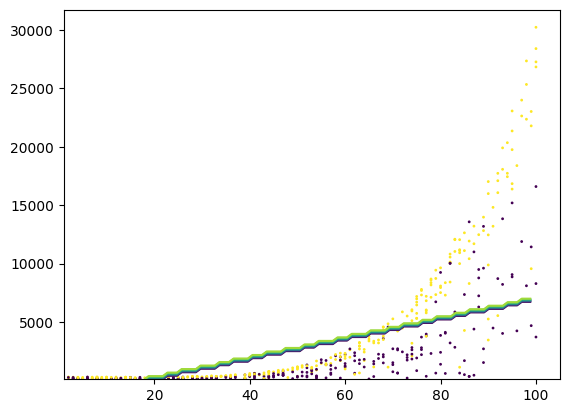

In [74]:
import matplotlib.pyplot as plt

plt.contour(xx, yy, z) #Estamos colocando no grafico os dados do eixo_x (horizontal), do eixo_y(vertical) e da linha que criamos onde a maquina irá nos mostrar a taxa de finalização, onde a parte mais baixa da linha é
#projetoscom menos chance de ser finalizado e mais alta projetos com mais chance de ser finalizados *ATENÇÃO*: o xx e o yy foi tirado dos dados, ou seja, não as respostas certas e o z são o que a maquina acha, ou seja, o que ela entendeu dos teates
plt.scatter(teste_x["horas_esperadas"], teste_x["preco"], c=teste_y, s=1)
#o nosso grafico mostra uma linha muito simples para explicas como ele detecta os projetos que serão terminados ou não, sedo qie os pontos mostra no grafico muito mais complexo, por isso o LinearSVC é muito simples e não consegue aprender a relação complexa não-linear